# PoC: E-Shop Clothing 2008 — EDA, Regression and Classification

This is a **proof of concept (PoC)** for the Part 2 project. The purpose of the PoC is, as per the assignment, *not* to go into details but to show that the entire pipeline — from raw data to a trained and evaluated model — can be built. Details, fine-tuning and deeper analysis are saved for after the instructor has approved the dataset and direction.

Dataset: **Clickstream data for online shopping** ("E-Shop Clothing 2008" on Kaggle / UCI Machine Learning Repository) — 165,474 rows of clickstream data from a Polish online store (maternity clothing), collected April–August 2008. 14 columns, no missing values.

Pipeline in this notebook:
1. Load and clean data
2. EDA (exploratory data analysis)
3. Regression — predict price
4. Classification — predict main category
5. Conclusion

## 0. Download the dataset

Download the CSV file from Kaggle (search for "e-shop clothing 2008") or [UCI Machine Learning Repository](https://archive.ics.uci.edu/dataset/553/clickstream+data+for+online+shopping), and place the file in the same folder as this notebook. Change `DATA_PATH` below if the filename differs from the default.

In [1]:
import os
DATA_PATH = os.path.join(os.path.dirname(os.path.abspath('__file__')), 'e-shop clothing 2008.csv')

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

In [3]:
# The file is semicolon-separated in the original source; sep=None + engine="python" auto-detects the delimiter
df_raw = pd.read_csv(DATA_PATH, sep=None, engine="python")
print("Rows, columns:", df_raw.shape)
df_raw.head()

Rows, columns: (165474, 14)


,year,month,day,order,country,session ID,page 1 (main category),page 2 (clothing model),colour,location,model photography,price,price 2,page
0,2008,4,1,1,29,1,1,A13,1,5,1,28,2,1
1,2008,4,1,2,29,1,1,A16,1,6,1,33,2,1
2,2008,4,1,3,29,1,2,B4,10,2,1,52,1,1
3,2008,4,1,4,29,1,2,B17,6,6,2,38,2,1
4,2008,4,1,5,29,1,2,B8,4,3,2,52,1,1


## 1. Clean and prepare data

In [4]:
def normalize_columns(columns):
    clean = []
    for c in columns:
        c = str(c).strip().lower()
        c = c.replace("\u00e4", "a").replace("\u00f6", "o").replace("\u00e5", "a")
        for ch in ["(", ")", "-", "/"]:
            c = c.replace(ch, " ")
        c = "_".join(c.split())
        clean.append(c)
    return clean

df = df_raw.copy()
df.columns = normalize_columns(df.columns)
df.columns.tolist()

['year',
 'month',
 'day',
 'order',
 'country',
 'session_id',
 'page_1_main_category',
 'page_2_clothing_model',
 'colour',
 'location',
 'model_photography',
 'price',
 'price_2',
 'page']

In [5]:
# Code books according to the dataset documentation (UCI / Kaggle "data description").
# Always double-check against the dataset description before presenting results.
MAIN_CATEGORY_MAP = {1: "trousers", 2: "skirts", 3: "blouses", 4: "sale"}
COLOUR_MAP = {
    1: "beige", 2: "black", 3: "blue", 4: "brown", 5: "burgundy", 6: "gray",
    7: "green", 8: "navy blue", 9: "of many colors", 10: "olive", 11: "pink",
    12: "red", 13: "violet", 14: "white",
}
LOCATION_MAP = {
    1: "top left", 2: "top middle", 3: "top right",
    4: "bottom left", 5: "bottom middle", 6: "bottom right",
}
MODEL_PHOTOGRAPHY_MAP = {1: "en face", 2: "profile"}
PRICE_ABOVE_AVG_MAP = {1: "yes", 2: "no"}

df["main_category"] = df["page_1_main_category"].map(MAIN_CATEGORY_MAP)
df["colour_name"] = df["colour"].map(COLOUR_MAP)
df["location_name"] = df["location"].map(LOCATION_MAP)
df["model_photography_name"] = df["model_photography"].map(MODEL_PHOTOGRAPHY_MAP)
df["price_above_avg"] = df["price_2"].map(PRICE_ABOVE_AVG_MAP)

df["date"] = pd.to_datetime(dict(year=df["year"], month=df["month"], day=df["day"]))

print("Missing values per column (after mapping):")
print(df.isna().sum())
df.head()

Missing values per column (after mapping):
year                      0
month                     0
day                       0
order                     0
country                   0
session_id                0
page_1_main_category      0
page_2_clothing_model     0
colour                    0
location                  0
model_photography         0
price                     0
price_2                   0
page                      0
main_category             0
colour_name               0
location_name             0
model_photography_name    0
price_above_avg           0
date                      0
dtype: int64


,year,month,day,order,country,session_id,page_1_main_category,page_2_clothing_model,colour,location,model_photography,price,price_2,page,main_category,colour_name,location_name,model_photography_name,price_above_avg,date
0,2008,4,1,1,29,1,1,A13,1,5,1,28,2,1,trousers,beige,bottom middle,en face,no,2008-04-01
1,2008,4,1,2,29,1,1,A16,1,6,1,33,2,1,trousers,beige,bottom right,en face,no,2008-04-01
2,2008,4,1,3,29,1,2,B4,10,2,1,52,1,1,skirts,olive,top middle,en face,yes,2008-04-01
3,2008,4,1,4,29,1,2,B17,6,6,2,38,2,1,skirts,gray,bottom right,profile,no,2008-04-01
4,2008,4,1,5,29,1,2,B8,4,3,2,52,1,1,skirts,brown,top right,profile,yes,2008-04-01


## 2. EDA (Exploratory Data Analysis)

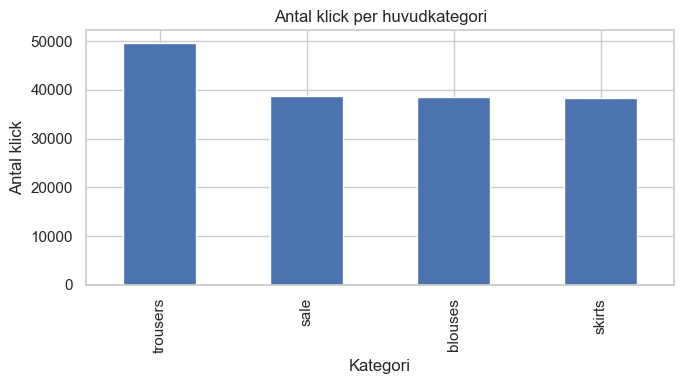

In [6]:
plt.figure(figsize=(7, 4))
df["main_category"].value_counts().plot(kind="bar", color="#4C72B0")
plt.title("Number of clicks per main category")
plt.xlabel("Category"); plt.ylabel("Number of clicks")
plt.tight_layout()
plt.show()

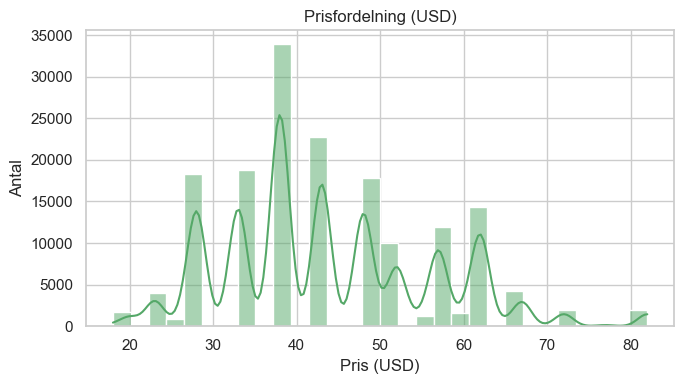

In [7]:
plt.figure(figsize=(7, 4))
sns.histplot(df["price"], bins=30, kde=True, color="#55A868")
plt.title("Price distribution (USD)")
plt.xlabel("Price (USD)"); plt.ylabel("Count")
plt.tight_layout()
plt.show()

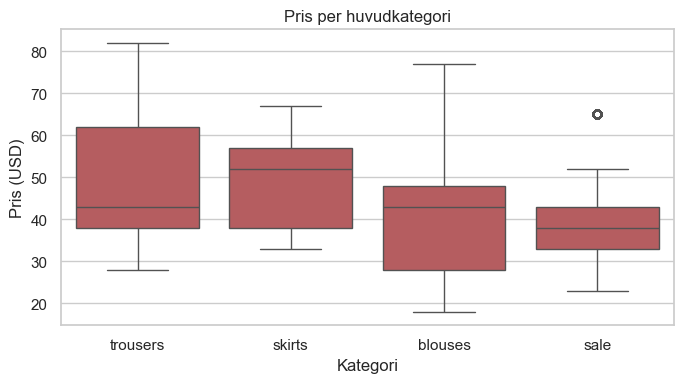

In [8]:
plt.figure(figsize=(7, 4))
sns.boxplot(data=df, x="main_category", y="price", color="#C44E52")
plt.title("Price per main category")
plt.xlabel("Category"); plt.ylabel("Price (USD)")
plt.tight_layout()
plt.show()

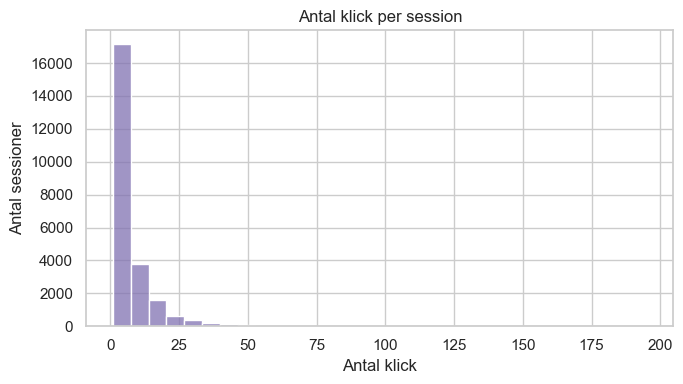

count    24026.000000
mean         6.887289
std          8.995161
min          1.000000
25%          2.000000
50%          4.000000
75%          8.000000
max        195.000000
Name: order, dtype: float64

In [9]:
clicks_per_session = df.groupby("session_id")["order"].max()
plt.figure(figsize=(7, 4))
sns.histplot(clicks_per_session, bins=30, color="#8172B2")
plt.title("Number of clicks per session")
plt.xlabel("Number of clicks"); plt.ylabel("Number of sessions")
plt.tight_layout()
plt.show()
clicks_per_session.describe()

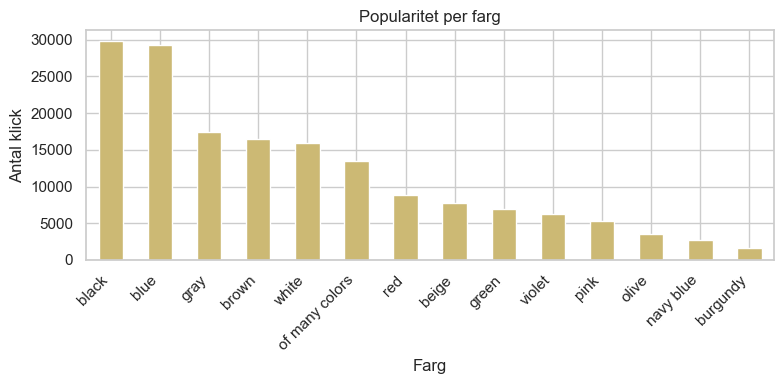

In [10]:
plt.figure(figsize=(8, 4))
df["colour_name"].value_counts().plot(kind="bar", color="#CCB974")
plt.title("Popularity by colour")
plt.xlabel("Colour"); plt.ylabel("Number of clicks")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## 3. Regression: predict price (PoC)

Goal (PoC): show that a pipeline from features to a trained regression model and a metric works — not to optimise the model.

In [11]:
from sklearn.tree import DecisionTreeRegressor

regression_features = ["main_category", "colour_name", "location_name", "model_photography_name", "country", "order", "page"]
target_reg = "price"

X = df[regression_features]
y = df[target_reg]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

categorical_cols = ["main_category", "colour_name", "location_name", "model_photography_name"]

preprocess = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
], remainder="passthrough")

reg_models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(max_depth=10, random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
}

print(f"{'Model':<20} {'MAE':>8} {'RMSE':>8} {'R^2':>8}")
print("-" * 46)
for name, model in reg_models.items():
    pipe = Pipeline([("prep", preprocess), ("model", model)])
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    mae  = mean_absolute_error(y_test, y_pred)
    rmse = mean_squared_error(y_test, y_pred) ** 0.5
    r2   = r2_score(y_test, y_pred)
    print(f"{name:<20} {round(mae,2):>8} {round(rmse,2):>8} {round(r2,3):>8}")

MAE : 2.17
RMSE: 5.57
R^2 : 0.804


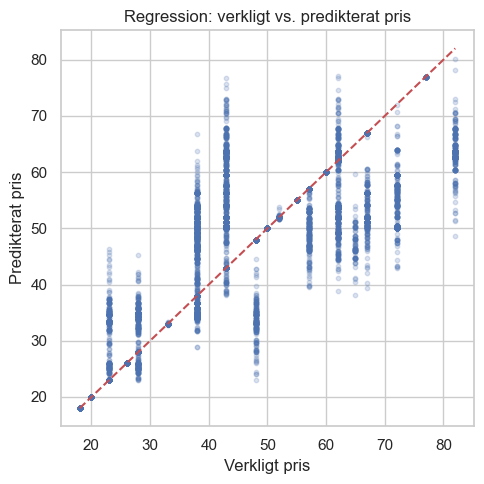

In [12]:
plt.figure(figsize=(5, 5))
plt.scatter(y_test, y_pred, alpha=0.2, s=10)
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
plt.plot(lims, lims, "r--")
plt.xlabel("Actual price"); plt.ylabel("Predicted price")
plt.title("Regression: actual vs. predicted price")
plt.tight_layout()
plt.show()

## 4. Classification: predict main category (PoC)

Goal (PoC): show that a pipeline from features to a trained classification model and a metric (accuracy) works.

In [13]:
from sklearn.tree import DecisionTreeClassifier

classification_features = ["price", "colour_name", "location_name", "model_photography_name", "country", "order", "page"]
target_clf = "main_category"

Xc = df[classification_features]
yc = df[target_clf]

Xc_train, Xc_test, yc_train, yc_test = train_test_split(
    Xc, yc, test_size=0.2, random_state=42, stratify=yc
)

categorical_cols_c = ["colour_name", "location_name", "model_photography_name"]

preprocess_c = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols_c),
], remainder="passthrough")

clf_models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(max_depth=10, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
}

print(f"{'Model':<22} {'Accuracy':>10}")
print("-" * 34)
for name, model in clf_models.items():
    pipe = Pipeline([("prep", preprocess_c), ("model", model)])
    pipe.fit(Xc_train, yc_train)
    yc_pred = pipe.predict(Xc_test)
    print(f"{name:<22} {round(accuracy_score(yc_test, yc_pred), 3):>10}")

# Detailed report for the best model (Random Forest)
best_pipe = Pipeline([("prep", preprocess_c), ("model", RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1))])
best_pipe.fit(Xc_train, yc_train)
yc_pred_best = best_pipe.predict(Xc_test)
print()
print("Random Forest — detailed report:")
print(classification_report(yc_test, yc_pred_best))

Accuracy: 0.989

              precision    recall  f1-score   support

     blouses       1.00      1.00      1.00      7715
        sale       1.00      0.99      0.99      7749
      skirts       0.99      0.97      0.98      7682
    trousers       0.98      0.99      0.98      9949

    accuracy                           0.99     33095
   macro avg       0.99      0.99      0.99     33095
weighted avg       0.99      0.99      0.99     33095



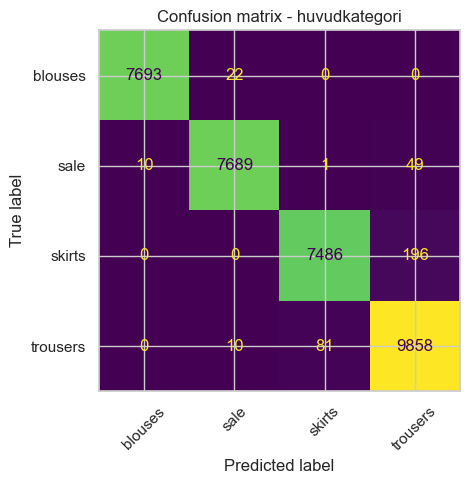

In [14]:
fig, ax = plt.subplots(figsize=(5, 5))
ConfusionMatrixDisplay.from_predictions(yc_test, yc_pred, ax=ax, xticks_rotation=45, colorbar=False)
plt.title("Confusion matrix - main category")
plt.tight_layout()
plt.show()

## 5. Conclusion (PoC)

The pipeline works end-to-end: data was loaded, cleaned, explored (EDA), and two models (regression + classification) were trained and evaluated on test data.

**Next steps (after check-in with the instructor):**
- More/better features (e.g. time-based features, product code `page_2_clothing_model`).
- Test more models and tune hyperparameters.
- Investigate class imbalance in main category (`main_category`) and potentially address it.
- Discuss limitations: data from 2008, a single store/market.